# Stroke Risk Prediction — Modeling (V1)

**Dataset** : Ping Wang (2024), *Imbalanced Data-based Prediction and Risk Factor Analysis of Stroke*, Mendeley Data. DOI: [10.17632/xggs239bnw.1](https://doi.org/10.17632/xggs239bnw.1)

**Prérequis** : `2_Preprocessing_v1.ipynb` → génère `df_clean.csv`  
**Sortie** : `pipeline.pkl` + `features.pkl`

---

> **Version V1 — Baseline simple**
> - Données : `df_clean.csv` — 35 features originales, toutes utilisées
> - Split + StandardScaler appliqués ici → zéro data leakage
> - 3 modèles : Logistic Regression, Random Forest, XGBoost
> - Paramètres par défaut — pas de tuning
> - recall ≈ 0% attendu sur la classe stroke
> - **Pas de sélection de features**
> - Métrique prioritaire : **Recall** — faux négatif = AVC non détecté

## 1. Imports

In [5]:
import sys
sys.path.insert(0, './src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix
)

import importlib
import config
importlib.reload(config)

from config import TARGET, RANDOM_STATE, DATA_PATH, CLEAN_PATH, check_data_quality, load_features

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

print('Libraries loaded.')
print(f'DATA_PATH  : {DATA_PATH}')
print(f'CLEAN_PATH : {CLEAN_PATH}')
print(f'TARGET     : {TARGET}')
print(f'RANDOM_STATE = {RANDOM_STATE}')

Libraries loaded.
DATA_PATH  : ../dataset/data.csv
CLEAN_PATH : ../dataset/data_clean/df_clean.csv
TARGET     : stroke
RANDOM_STATE = 42


## 2. Chargement des Variables et du Dataset

In [6]:
# Variables depuis src/features.json — 35 features originales
TARGET, CATEGORICAL_VARS, NUMERICAL_VARS, ALL_FEATURES = load_features()

print(f'\nFeatures totales  : {len(ALL_FEATURES)}')
print(f'  Catégorielles   : {len(CATEGORICAL_VARS)}')
print(f'  Numériques      : {len(NUMERICAL_VARS)}')

features.json charge :
  target           : stroke
  categorical_vars : 15 variables
  numerical_vars   : 20 variables

Features totales  : 35
  Catégorielles   : 15
  Numériques      : 20


In [7]:
# Chargement df_clean.csv
df = pd.read_csv(CLEAN_PATH)

is_clean = check_data_quality(df)
if not is_clean:
    raise ValueError('Dataset non propre — relancer 2_Preprocessing_v1.ipynb.')

  Data Quality Report

Valeurs manquantes : 0
  Aucune valeur manquante.

Doublons : 0
  Aucun doublon.

Shape : 4603 lignes x 36 colonnes


## 3. Train / Test Split

Split réalisé **ici dans le Modeling** — permet au StandardScaler  
d'être fitté uniquement sur `X_train` → **zéro data leakage**.

- Ratio : 80% train / 20% test
- `stratify=y` : conserve le ratio 92%/8% dans chaque split
- `random_state=RANDOM_STATE` : reproductibilité garantie

In [8]:
X = df[ALL_FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print('=== Train / Test Split ===')
print(f'X_train : {X_train.shape}  |  X_test : {X_test.shape}')
vc_train = y_train.value_counts()
vc_test  = y_test.value_counts()
print(f'\ny_train — No stroke: {vc_train[0]} ({vc_train[0]/len(y_train)*100:.1f}%)  Stroke: {vc_train[1]} ({vc_train[1]/len(y_train)*100:.1f}%)')
print(f'y_test  — No stroke: {vc_test[0]}  ({vc_test[0]/len(y_test)*100:.1f}%)  Stroke: {vc_test[1]}  ({vc_test[1]/len(y_test)*100:.1f}%)')

=== Train / Test Split ===
X_train : (3682, 35)  |  X_test : (921, 35)

y_train — No stroke: 3392 (92.1%)  Stroke: 290 (7.9%)
y_test  — No stroke: 849  (92.2%)  Stroke: 72  (7.8%)


## 4. Normalisation — StandardScaler

`fit` sur `X_train` uniquement → zéro data leakage.  
Appliqué sur `NUMERICAL_VARS` seulement — catégorielles non scalées.

In [9]:
scaler = StandardScaler()

X_train = X_train.copy()
X_test  = X_test.copy()

X_train[NUMERICAL_VARS] = scaler.fit_transform(X_train[NUMERICAL_VARS])
X_test[NUMERICAL_VARS]  = scaler.transform(X_test[NUMERICAL_VARS])

print('StandardScaler applique sur NUMERICAL_VARS uniquement.')
print(f'  Mean X_train apres scaling ≈ 0 : {X_train[NUMERICAL_VARS].mean().abs().mean():.4f}')
print(f'  Std  X_train apres scaling ≈ 1 : {X_train[NUMERICAL_VARS].std().mean():.4f}')
print(f'  Categorielle non scalees       : {len(CATEGORICAL_VARS)}')

StandardScaler applique sur NUMERICAL_VARS uniquement.
  Mean X_train apres scaling ≈ 0 : 0.0000
  Std  X_train apres scaling ≈ 1 : 1.0001
  Categorielle non scalees       : 15


## 5. Définition des Modèles

3 modèles — paramètres par défaut, **pas de tuning en V1**.

| Modèle | Type | Justification |
|---|---|---|
| Logistic Regression | Linéaire | Baseline interprétable, référence classique |
| Random Forest | Ensemble bagging | Robuste sans tuning, gère la non-linéarité |
| XGBoost | Ensemble boosting | Performant sur données médicales tabulaires |

In [10]:
models = {
    'Logistic Regression': LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=1000
    ),
    'Random Forest': RandomForestClassifier(
        random_state=RANDOM_STATE
    ),
    'XGBoost': XGBClassifier(
        random_state=RANDOM_STATE,
        eval_metric='logloss',
        verbosity=0
    )
}

print(f'{len(models)} modeles — parametres par defaut, sans SMOTE, sans tuning')
for name in models:
    print(f'  - {name}')

3 modeles — parametres par defaut, sans SMOTE, sans tuning
  - Logistic Regression
  - Random Forest
  - XGBoost


## 6. Entraînement et Évaluation

Métrique prioritaire : **Recall** — dans un contexte médical,  
un faux négatif (AVC non détecté) est bien plus grave qu'un faux positif.

In [11]:
results        = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall'   : round(recall_score(y_test, y_pred, zero_division=0), 4),
        'F1'       : round(f1_score(y_test, y_pred, zero_division=0), 4),
        'AUC-ROC'  : round(roc_auc_score(y_test, y_prob), 4),
    })
    trained_models[name] = model

results_df = pd.DataFrame(results).set_index('Model')
print('=== Résultats V1 ===')
print(results_df.to_string())

=== Résultats V1 ===
                     Accuracy  Precision  Recall      F1  AUC-ROC
Model                                                            
Logistic Regression    0.9229       1.00  0.0139  0.0274   0.6202
Random Forest          0.9218       0.00  0.0000  0.0000   0.6092
XGBoost                0.9197       0.25  0.0139  0.0263   0.5933


## 7. Visualisation des Résultats

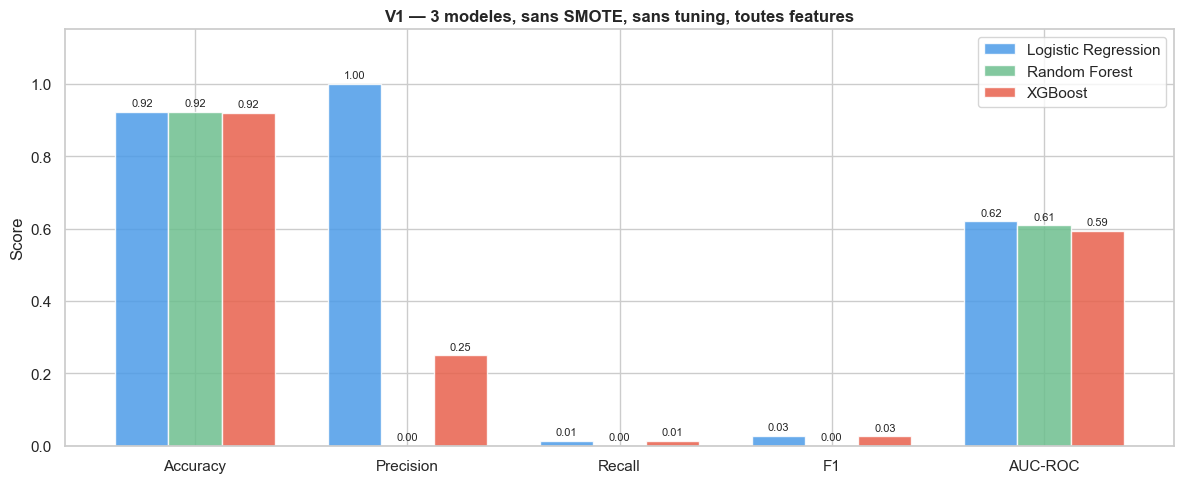

In [12]:
# Comparaison des metriques
metrics_cols = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC-ROC']
colors       = ['#4C9BE8', '#6DBF8E', '#E8614C']

fig, ax = plt.subplots(figsize=(12, 5))
x     = np.arange(len(metrics_cols))
width = 0.25

for i, (name, row) in enumerate(results_df.iterrows()):
    vals = [row[m] for m in metrics_cols]
    bars = ax.bar(x + i * width, vals, width, label=name,
                  color=colors[i], alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics_cols)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('V1 — 3 modeles, sans SMOTE, sans tuning, toutes features',
             fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

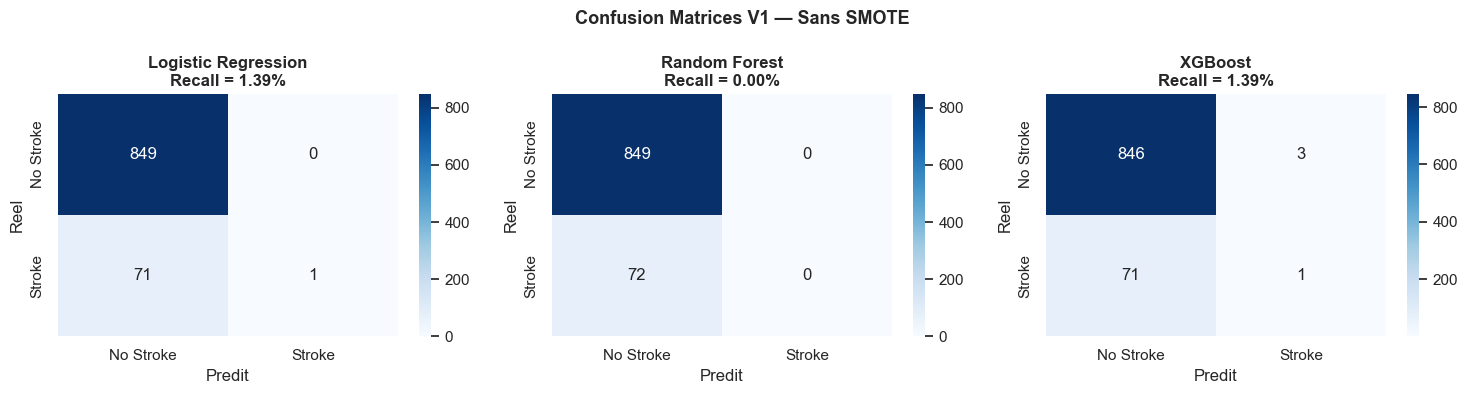

In [13]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, (name, model) in enumerate(trained_models.items()):
    y_pred     = model.predict(X_test)
    cm         = confusion_matrix(y_test, y_pred)
    recall_val = recall_score(y_test, y_pred, zero_division=0)

    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['No Stroke', 'Stroke'],
        yticklabels=['No Stroke', 'Stroke'],
        ax=axes[i]
    )
    axes[i].set_title(f'{name}\nRecall = {recall_val:.2%}', fontweight='bold')
    axes[i].set_ylabel('Reel')
    axes[i].set_xlabel('Predit')

plt.suptitle('Confusion Matrices V1 — Sans SMOTE', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

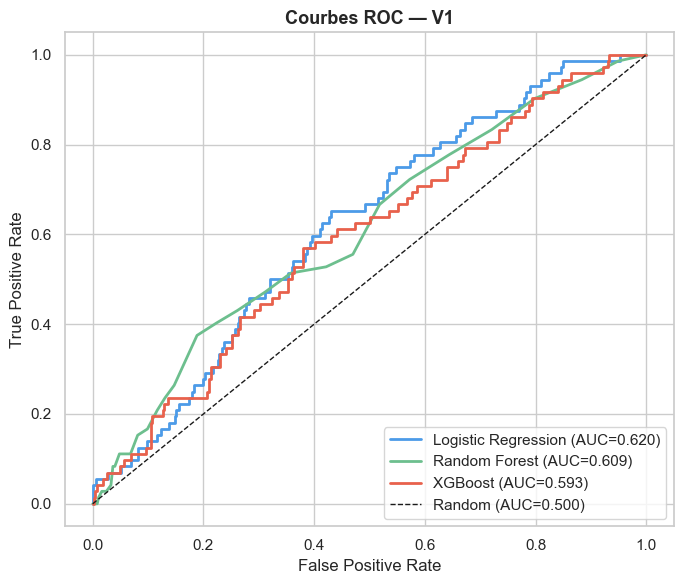

In [14]:
# Courbes ROC
fig, ax = plt.subplots(figsize=(7, 6))

for i, (name, model) in enumerate(trained_models.items()):
    y_prob      = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc         = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, color=colors[i], linewidth=2,
            label=f'{name} (AUC={auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC=0.500)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Courbes ROC — V1', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 8. Constat V1 — Justification empirique

In [15]:
print('=== Constat V1 ===')
print()
for name, row in results_df.iterrows():
    print(f'{name} :')
    print(f'  Accuracy : {row["Accuracy"]:.2%}  <- elevee car modele predit toujours 0')
    print(f'  Recall   : {row["Recall"]:.2%}  <- proche 0% = AVC non detectes')
    print()

print('Conclusion :')
print('  Sans SMOTE, les 3 modeles ignorent la classe stroke (minoritaire).')
print('  Recall proche de 0% = cliniquement inutilisable.')
print()
print('  Justification V2 :')
print('  → SMOTE sur X_train → equilibre des classes → recall augmente')
print('  → SelectKBest/PCA → selection des features pertinentes')
print('  → RandomizedSearchCV scoring=recall → meilleurs hyperparametres')

=== Constat V1 ===

Logistic Regression :
  Accuracy : 92.29%  <- elevee car modele predit toujours 0
  Recall   : 1.39%  <- proche 0% = AVC non detectes

Random Forest :
  Accuracy : 92.18%  <- elevee car modele predit toujours 0
  Recall   : 0.00%  <- proche 0% = AVC non detectes

XGBoost :
  Accuracy : 91.97%  <- elevee car modele predit toujours 0
  Recall   : 1.39%  <- proche 0% = AVC non detectes

Conclusion :
  Sans SMOTE, les 3 modeles ignorent la classe stroke (minoritaire).
  Recall proche de 0% = cliniquement inutilisable.

  Justification V2 :
  → SMOTE sur X_train → equilibre des classes → recall augmente
  → SelectKBest/PCA → selection des features pertinentes
  → RandomizedSearchCV scoring=recall → meilleurs hyperparametres


## 9. Sauvegarde — pipeline.pkl + features.pkl

In [17]:
# Meilleur modele selon Recall
best_name  = results_df['Recall'].idxmax()
best_model = trained_models[best_name]

print(f'Meilleur modele selon Recall : {best_name}')
print(f'  Recall  : {results_df.loc[best_name, "Recall"]:.4f}')
print(f'  AUC-ROC : {results_df.loc[best_name, "AUC-ROC"]:.4f}')

# pipeline_v1.pkl
pipeline = Pipeline(steps=[('model', best_model)])
with open('pipeline_v1.pkl', 'wb') as f:
    pickle.dump(pipeline, f)

# features_v1.pkl — 35 features utilisees
with open('features_v1.pkl', 'wb') as f:
    pickle.dump(ALL_FEATURES, f)

print()
print('Artefacts sauvegardes :')
print('  pipeline_v1.pkl — meilleur modele V1')
print(f'  features_v1.pkl — {len(ALL_FEATURES)} features utilisees')

Meilleur modele selon Recall : Logistic Regression
  Recall  : 0.0139
  AUC-ROC : 0.6202

Artefacts sauvegardes :
  pipeline_v1.pkl — meilleur modele V1
  features_v1.pkl — 35 features utilisees
